# 1. Environment Setup & Data Loading

In [1]:
#  Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import kstest, f_oneway, zscore

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate, GridSearchCV, cross_val_score, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, 
                            roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.dpi'        : 130,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F8F9FA',
    'axes.grid'         : True,
    'grid.alpha'        : 0.35,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'serif',
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'axes.titleweight'  : 'bold',
})

# Colour system
C = {
    'navy'   : '#0F2044', 'blue'  : '#1A56A0', 'teal'  : '#0D7A6A',
    'green'  : '#276749', 'amber' : '#B45309', 'red'   : '#991B1B',
    'slate'  : '#475569', 'gray'  : '#94A3B8',
}
DEPT_COLORS  = ['#1A56A0','#0D7A6A','#B45309','#991B1B','#5B21B6','#276749']
SRC_COLORS   = ['#1A56A0','#0D7A6A','#B45309','#991B1B']

print('Libraries loaded')
for lib, mod in [('pandas', pd), ('numpy', np), ('scipy', stats), ('seaborn', sns), ('sklearn','sklearn')]:
    try:
        v = mod.__version__
    except:
        import sklearn; v = sklearn.__version__
    print(f'   {lib}: {v}')

Libraries loaded
   pandas: 2.3.3
   numpy: 2.3.5
   scipy: 1.7.2
   seaborn: 0.13.2
   sklearn: 1.7.2


In [2]:
# Data Loading
DATA_PATH = 'recruitment_efficiency_improved.csv'

df_raw = pd.read_csv(DATA_PATH)
df     = df_raw.copy()

print(f'Dataset loaded: {DATA_PATH}')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
print('── Schema')
print(df.dtypes)
print()
print('── First 5 rows')
df.head()

Dataset loaded: recruitment_efficiency_improved.csv
Shape: 5,000 rows × 8 columns

── Schema
recruitment_id             int64
department                object
job_title                 object
num_applicants             int64
time_to_hire_days          int64
cost_per_hire            float64
source                    object
offer_acceptance_rate    float64
dtype: object

── First 5 rows


,recruitment_id,department,job_title,num_applicants,time_to_hire_days,cost_per_hire,source,offer_acceptance_rate
0,1,Engineering,Software Engineer,280,24,1400.38,Referral,0.98
1,2,Sales,Account Executive,262,7,2730.45,LinkedIn,0.84
2,3,Product,UX Designer,11,76,5286.12,LinkedIn,0.83
3,4,Engineering,DevOps Engineer,238,26,5255.78,Recruiter,0.49
4,5,HR,Talent Acquisition,275,37,4987.03,LinkedIn,0.79


# 4. Feature Engineering & Selection Strategy

Approach: Because all numeric-vs-target correlations are near-zero and OAR is near-uniformly distributed.

## 4.1. Target Variable Engineering

Binary classification at the 70% threshold aligns with the KPI Depot benchmark for OAR, where ≥70% represents the minimum acceptable performance level (no immediate intervention required) and is used here as the boundary for 'high-performing hire.' This threshold reflects the industry standard at which recruitment outcomes are considered operationally stable.  
Business logic: A recruiter needs to know "Will this offer be accepted?" Not "What will the exact rate be?"

── Target Variable Summary
Binary (≥0.70):  1=2,175  (43.5%)  0=2,825  (56.5%)
Imbalance ratio  1.30:1 (Low:High)

Action: Use binary target (target_high_oar) as primary ML target.


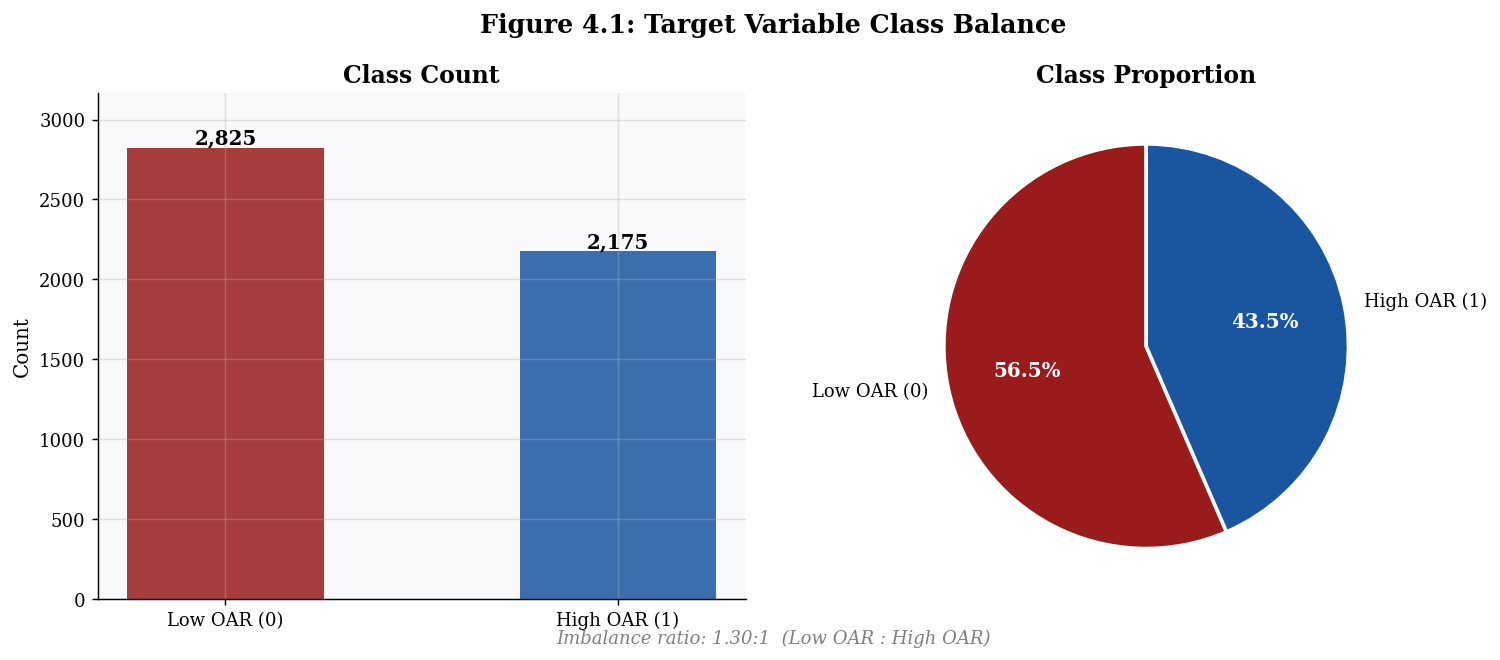

In [3]:
# Target Variable: Binary Classification
df_feat = df.copy()

# Primary binary target
df_feat['target_high_oar'] = (df_feat['offer_acceptance_rate'] >= 0.70).astype(int)

print('── Target Variable Summary')
print(f'Binary (≥0.70):  1={df_feat["target_high_oar"].sum():,}  ({100*df_feat["target_high_oar"].mean():.1f}%)  '
      f'0={len(df_feat)-df_feat["target_high_oar"].sum():,}  ({100*(1-df_feat["target_high_oar"].mean()):.1f}%)')
print(f'Imbalance ratio  {(1-df_feat["target_high_oar"].mean())/df_feat["target_high_oar"].mean():.2f}:1 (Low:High)')
print('\nAction: Use binary target (target_high_oar) as primary ML target.')

# Binary Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 4.1: Target Variable Class Balance',
             fontweight='bold', fontsize=14)

counts = df_feat['target_high_oar'].value_counts().sort_index()
labels = ['Low OAR (0)', 'High OAR (1)']
colors = [C['red'], C['blue']]

# Left: Bar chart
ax = axes[0]
bars = ax.bar(labels, counts.values, color=colors, alpha=0.85, width=0.5)
ax.set_title('Class Count')
ax.set_ylabel('Count')
for b in bars:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 20,
            f'{int(b.get_height()):,}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, counts.max() * 1.12)

# Right: Pie chart
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    counts.values, labels=labels,
    autopct='%1.1f%%', colors=colors,
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(11); t.set_fontweight('bold'); t.set_color('white')
ax.set_title('Class Proportion')

# Imbalance annotation
ratio = counts[0] / counts[1]
fig.text(0.5, 0.01, f'Imbalance ratio: {ratio:.2f}:1  (Low OAR : High OAR)',
         ha='center', fontsize=10, style='italic', color='grey')

plt.tight_layout()
plt.savefig('fig_4.1_target_class_balance.png', bbox_inches='tight', dpi=150)
plt.show()

## 4.2. New Feature Engineering

Raw features alone show near-zero signal. Derived features capture business-domain knowledge and potential non-linear interactions.

In [4]:
# Efficiency Ratios
# Logic: High spend with few applicants signals poor sourcing reach. Candidates sense a disorganized or desperate hiring process, 
#        which erodes confidence and lowers their willingness to accept an offer.
df_feat['cost_per_applicant'] = df_feat['cost_per_hire'] / df_feat['num_applicants']
# Logic: Captures daily resource burn rate. A fast but expensive hire suggests over-reliance on external recruiters; 
#        a slow but cheap one implies passive sourcing. Both extremes may indicate a poorly structured process that affects candidate experience.
df_feat['cost_per_day'] = df_feat['cost_per_hire'] / df_feat['time_to_hire_days']
# Logic: Pipeline velocity. Very low velocity signals an unattractive role or poorly written JD. 
#        Very high velocity means bulk low-intent applications flood the pipeline. Both extremes dilute match quality and reduce OAR.
df_feat['applicants_per_day'] = df_feat['num_applicants'] / df_feat['time_to_hire_days']

# Role context
# Logic: Senior candidates typically receive multiple competing offers and engage in harder salary negotiations. 
#        The longer decision cycle and higher market demand for their skills structurally depress offer acceptance rates for these roles.
df_feat['is_senior_role'] = (
    df['job_title']
    .str.contains(r'\b(manager|specialist|executive|strategist)\b', case=False, na=False)
    .astype(int)
)

# Auxiliary column for the dept+source combination encoding target
df_feat['dept_src_key'] = (
    df_feat['department'].astype(str) + '_' + df_feat['source'].astype(str)
)

In [5]:
X = df_feat.drop(columns=['target_high_oar']).copy()
y = df_feat['target_high_oar'].copy()
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)
 
print(f"── Train-Test Split:")
print(f"Train : {X_train.shape[0]:,} rows   |  High OAR: {y_train.mean()*100:.1f}%")
print(f"Test  : {X_test.shape[0]:,}  rows  |  High OAR: {y_test.mean()*100:.1f}%")

# Difficulty Additive
# Logic: Combines normalized time and cost into a single difficulty score.
#        Higher score = harder recruitment process, which may reduce candidate enthusiasm and OAR.
time_mean_train = X_train['time_to_hire_days'].mean()
time_std_train  = X_train['time_to_hire_days'].std()
cost_mean_train = X_train['cost_per_hire'].mean()
cost_std_train  = X_train['cost_per_hire'].std()
 
X_train['difficulty_additive'] = (
    (X_train['time_to_hire_days'] - time_mean_train) / time_std_train +
    (X_train['cost_per_hire']     - cost_mean_train) / cost_std_train
) / 2
 
X_test['difficulty_additive'] = (
    (X_test['time_to_hire_days'] - time_mean_train) / time_std_train +
    (X_test['cost_per_hire']     - cost_mean_train) / cost_std_train
) / 2

# Logic: DREI = 1 when a record simultaneously beats its department median on all three KPIs (lower cost, faster hire, higher OAR).
#        This creates a binary flag that captures "outlier efficiency" relative to the candidate's own department context — signal that global features
#        cannot encode because they are insensitive to departmental baselines.
# Compute department medians from TRAIN ONLY
dept_medians = (
    X_train
    .assign(offer_acceptance_rate=df_feat.loc[y_train.index, 'offer_acceptance_rate'].values)
    .groupby('department')
    .agg({
        'cost_per_hire'        : 'median',
        'time_to_hire_days'    : 'median',
        'offer_acceptance_rate': 'median'
    })
    .rename(columns={
        'cost_per_hire'        : 'dept_median_cph',
        'time_to_hire_days'    : 'dept_median_tth',
        'offer_acceptance_rate': 'dept_median_oar'
    })
)

# Join medians into train
X_train = X_train.join(dept_medians, on='department')

# Add OAR back temporarily for comparison
X_train['offer_acceptance_rate_temp'] = (
    df_feat.loc[y_train.index, 'offer_acceptance_rate'].values
)

# Create DREI (train)
X_train['drei'] = (
    (X_train['cost_per_hire'] < X_train['dept_median_cph']) &
    (X_train['time_to_hire_days'] < X_train['dept_median_tth']) &
    (X_train['offer_acceptance_rate_temp'] > X_train['dept_median_oar'])
).astype(int)

# Apply SAME medians to TEST
X_test = X_test.join(dept_medians, on='department')

X_test['offer_acceptance_rate_temp'] = (
    df_feat.loc[y_test.index, 'offer_acceptance_rate'].values
)

# Create DREI (test)
X_test['drei'] = (
    (X_test['cost_per_hire'] < X_test['dept_median_cph']) &
    (X_test['time_to_hire_days'] < X_test['dept_median_tth']) &
    (X_test['offer_acceptance_rate_temp'] > X_test['dept_median_oar'])
).astype(int)

# Cleanup temporary/helper columns
drop_cols = [
    'dept_median_cph',
    'dept_median_tth',
    'dept_median_oar',
    'offer_acceptance_rate_temp'
]

X_train.drop(columns=drop_cols, inplace=True)
X_test.drop(columns=drop_cols, inplace=True)

print("\n── DREI Feature Created Successfully")
print(f"Train DREI positive rate : {X_train['drei'].mean()*100:.2f}%")
print(f"Test  DREI positive rate : {X_test['drei'].mean()*100:.2f}%")

# Target Encoding
# Logic: Group-level historical OAR as a proxy signal.
#        Fitted ONLY on y_train — X_test receives transform only.
GLOBAL_MEAN = y_train.mean()
SMOOTH_K    = 20
 
def fit_target_encoder(X_train, y_train, col, k=SMOOTH_K, global_mean=None):
    """
    Compute smoothed target encoding from the training set.
    encode(g) = (n_g * mean_g + k * global_mean) / (n_g + k)
    """
    if global_mean is None:
        global_mean = y_train.mean()
    temp = pd.DataFrame({'group': X_train[col].values, 'target': y_train.values})
    agg  = temp.groupby('group')['target'].agg(['mean', 'count'])
    mapping = ((agg['count'] * agg['mean'] + k * global_mean) / (agg['count'] + k)).to_dict()
    return mapping
 
def apply_target_encoder(X, col, mapping, global_mean=GLOBAL_MEAN):
    """
    Apply mapping to X[col].
    Unknown (unseen) categories → fall back to global_mean.
    """
    return X[col].map(mapping).fillna(global_mean)
 
# Fit from train
dept_map     = fit_target_encoder(X_train, y_train, 'department')
jobtitle_map = fit_target_encoder(X_train, y_train, 'job_title')
source_map   = fit_target_encoder(X_train, y_train, 'source')
deptsrc_map  = fit_target_encoder(X_train, y_train, 'dept_src_key')
 
# Apply to train
X_train['dept_oar_mean']        = apply_target_encoder(X_train, 'department',   dept_map)
X_train['jobtitle_oar_mean']    = apply_target_encoder(X_train, 'job_title',    jobtitle_map)
X_train['source_oar_mean']      = apply_target_encoder(X_train, 'source',       source_map)
X_train['dept_source_oar_mean'] = apply_target_encoder(X_train, 'dept_src_key', deptsrc_map)
 
# Apply to test (same mapping, y_test never touched)
X_test['dept_oar_mean']         = apply_target_encoder(X_test, 'department',   dept_map)
X_test['jobtitle_oar_mean']     = apply_target_encoder(X_test, 'job_title',    jobtitle_map)
X_test['source_oar_mean']       = apply_target_encoder(X_test, 'source',       source_map)
X_test['dept_source_oar_mean']  = apply_target_encoder(X_test, 'dept_src_key', deptsrc_map)
 
print(f"\n── Target Encoding — Global mean (train): {GLOBAL_MEAN:.4f}  |  K: {SMOOTH_K}")
print(f"Mapping department:")
for k, v in sorted(dept_map.items()):
    print(f"  {k:<15} → {v:.4f}")
print(f"\nMapping source:")
for k, v in sorted(source_map.items()):
    print(f"  {k:<15} → {v:.4f}")
print(f"\nMapping job_title:")
for k, v in sorted(jobtitle_map.items()):
    print(f"  {k:<35} → {v:.4f}")

print(f"\n── Anti-Leakage Validation:")
 
dept_map_test = fit_target_encoder(X_test, y_test, 'department')
print(f"Department encoding difference (train vs test) — delta must exist:")
for dept in dept_map:
    if dept in dept_map_test:
        delta = abs(dept_map[dept] - dept_map_test[dept])
        flag  = '✅ Different (safe)' if delta > 1e-6 else '❌ Identical!'
        print(f"  {dept:<15} train={dept_map[dept]:.4f}  test={dept_map_test[dept]:.4f}  |Δ|={delta:.6f}  {flag}")
 
corr_check = X_test['dept_oar_mean'].corr(y_test.reset_index(drop=True))
print(f"\nCorrelation of dept_oar_mean (test set) vs y_test : {corr_check:.4f}")
print(f"{'✅ Reasonable — no leakage detected' if abs(corr_check) < 0.9 else '❌ Too high!'}")
 
print(f"\nPipeline confirmation:")
print(f"- Ratio features created before split (target not touched)")
print(f"- difficulty_additive: mean & std fitted from X_train only")
print(f"- Target encoding fitted on y_train only")
print(f"- X_test receives transform only, y_test is not used")

FINAL_FEATURES = [
    'cost_per_applicant',
    'cost_per_day',
    'applicants_per_day',
    'is_senior_role',
    'difficulty_additive',
    'drei',
    'dept_oar_mean',
    'jobtitle_oar_mean',
    'source_oar_mean',
    'dept_source_oar_mean',
]
 
X_train_final = X_train[FINAL_FEATURES].copy()
X_test_final  = X_test[FINAL_FEATURES].copy()
 
# Evaluate correlations from TRAIN only
train_eval = X_train_final.copy()
train_eval['offer_acceptance_rate'] = df_feat.loc[y_train.index, 'offer_acceptance_rate'].values
train_eval['target_high_oar']       = y_train.values
 
corr_oar    = train_eval[FINAL_FEATURES + ['offer_acceptance_rate']].corr()['offer_acceptance_rate'].drop('offer_acceptance_rate')
corr_target = train_eval[FINAL_FEATURES + ['target_high_oar']].corr()['target_high_oar'].drop('target_high_oar')
corr_summary = pd.DataFrame({
    'Corr vs OAR (continuous)' : corr_oar,
    'Corr vs Target (binary)'  : corr_target,
    '|r|'                      : corr_oar.abs(),
}).sort_values('|r|', ascending=False)
 
print(f"\n── Correlation Evaluation (from Training Set):")
print(f"{'Feature':<28} {'r vs OAR':>10} {'r vs Target':>13} {'|r|':>8}")
print(f"{'-'*62}")
for feat, row in corr_summary.iterrows():
    print(f"{feat:<28} {row['Corr vs OAR (continuous)']:>10.4f} "
          f"{row['Corr vs Target (binary)']:>13.4f} {row['|r|']:>8.4f}")

── Train-Test Split:
Train : 4,000 rows   |  High OAR: 43.5%
Test  : 1,000  rows  |  High OAR: 43.5%

── DREI Feature Created Successfully
Train DREI positive rate : 12.47%
Test  DREI positive rate : 13.50%

── Target Encoding — Global mean (train): 0.4350  |  K: 20
Mapping department:
  Engineering     → 0.4412
  Finance         → 0.4203
  HR              → 0.4282
  Marketing       → 0.4772
  Product         → 0.4251
  Sales           → 0.4196

Mapping source:
  Job Portal      → 0.4394
  LinkedIn        → 0.4223
  Recruiter       → 0.4546
  Referral        → 0.4250

Mapping job_title:
  Account Executive                   → 0.4452
  Accountant                          → 0.4124
  Backend Developer                   → 0.4327
  Business Development Manager        → 0.3754
  Content Strategist                  → 0.4982
  Data Engineer                       → 0.4721
  DevOps Engineer                     → 0.4048
  Finance Manager                     → 0.4107
  Financial Analyst           

In [6]:
dept_medians

,dept_median_cph,dept_median_tth,dept_median_oar
department,,,
Engineering,5332.275,48.0,0.650
Finance,5293.855,48.0,0.630
HR,5300.235,44.0,0.650
Marketing,5188.515,47.0,0.665
Product,5208.430,46.0,0.640
Sales,4912.000,49.0,0.640


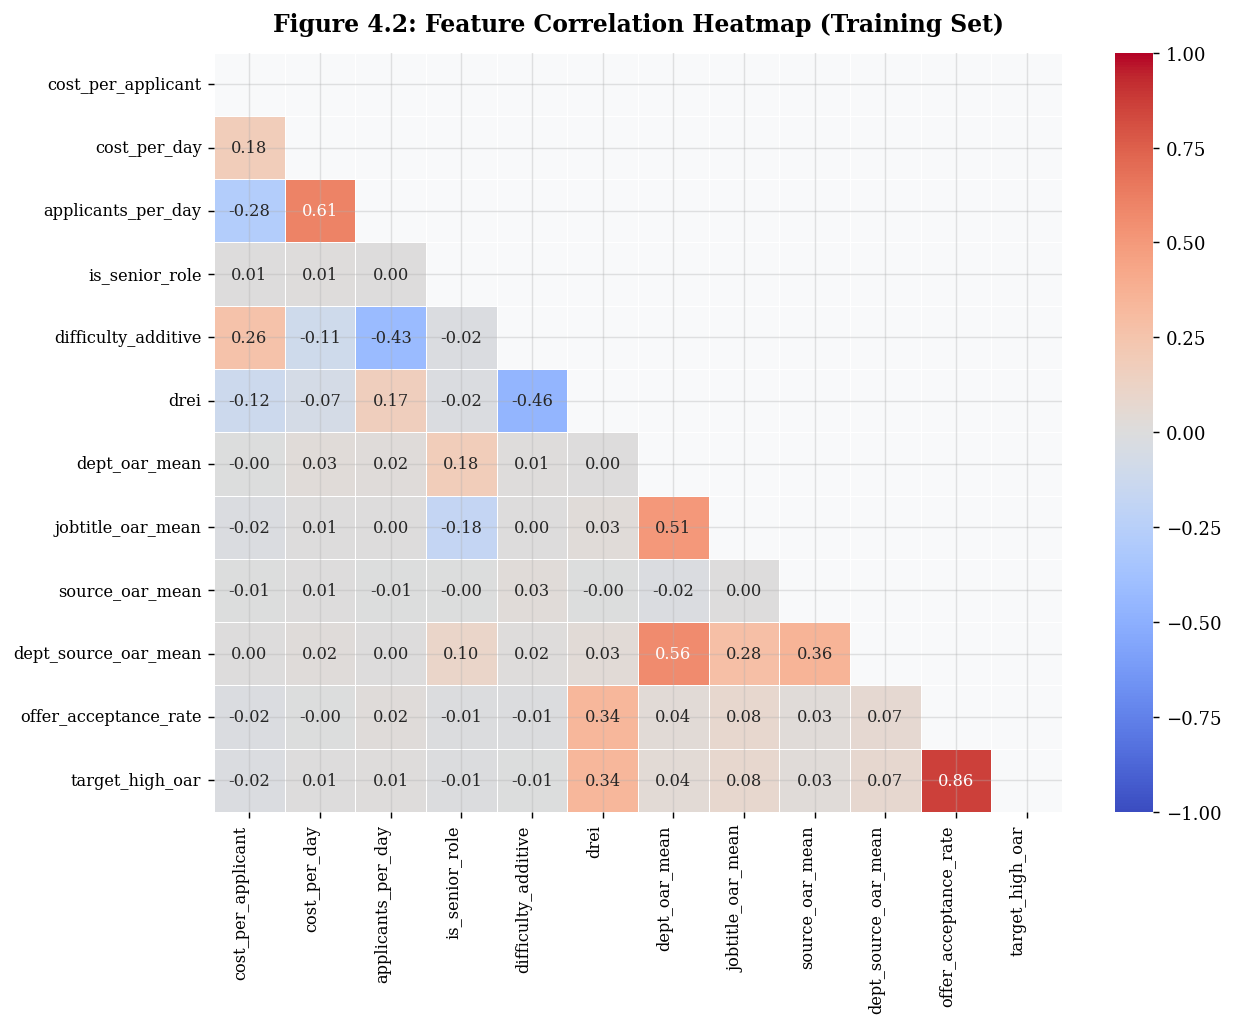

In [7]:
corr_matrix = X_train_final.copy()
corr_matrix['offer_acceptance_rate'] = df_feat.loc[y_train.index, 'offer_acceptance_rate'].values
corr_matrix['target_high_oar'] = y_train.values

corr_df = corr_matrix[FINAL_FEATURES + ['offer_acceptance_rate'] + ['target_high_oar']].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_df, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_df,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 9}
)
ax.set_title("Figure 4.2: Feature Correlation Heatmap (Training Set)", fontsize=13, pad=12)
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("fig_4.2_heatmap_features.png", dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Rename to be consistent 
X_tr = X_train_final.copy()
X_te = X_test_final.copy()

# Check missing & infinite values
X_tr.replace([np.inf, -np.inf], np.nan, inplace=True)
X_te.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in X_tr.columns:
    med = X_tr[col].median()
    X_tr[col].fillna(med, inplace=True)
    X_te[col].fillna(med, inplace=True)
print(f"Missing  — train: {X_tr.isnull().sum().sum()}  test: {X_te.isnull().sum().sum()}")
print(f"Infinite — train: {np.isinf(X_tr.values).sum()}  test: {np.isinf(X_te.values).sum()}")

FEATURES_TO_SCALE = [f for f in X_tr.columns if f not in ('is_senior_role', 'drei')]
FEATURES_NO_SCALE = ['is_senior_role', 'drei']

# StandardScaler only on continuous numeric features
std_scaler = StandardScaler()

# Fit on train, transform both
X_train_scaled_part = pd.DataFrame(
    std_scaler.fit_transform(X_tr[FEATURES_TO_SCALE]),
    columns=FEATURES_TO_SCALE, index=X_tr.index
)
X_test_scaled_part = pd.DataFrame(
    std_scaler.transform(X_te[FEATURES_TO_SCALE]),
    columns=FEATURES_TO_SCALE, index=X_te.index
)

# Merge back with is_senior_role which is not scaled
X_train_std = pd.concat([X_train_scaled_part, X_tr[FEATURES_NO_SCALE]], axis=1)
X_test_std  = pd.concat([X_test_scaled_part,  X_te[FEATURES_NO_SCALE]], axis=1)

# Reorder columns to match original order
X_train_std = X_train_std[X_tr.columns]
X_test_std  = X_test_std[X_te.columns]

# No scaling → Decision Tree, Random Forest, XGBoost
X_train_raw = X_tr.copy()
X_test_raw  = X_te.copy()

# Save outputs
for X_train_out, X_test_out, suffix in [
    (X_train_std, X_test_std, 'standard_scaled'),
    (X_train_raw, X_test_raw, 'raw'),
]:
    tr = X_train_out.copy(); tr['target_high_oar'] = y_train.values
    te = X_test_out.copy();  te['target_high_oar'] = y_test.values
    tr.to_csv(f'train_{suffix}.csv', index=False)
    te.to_csv(f'test_{suffix}.csv',  index=False)
    print(f"Saved: train_{suffix}.csv & test_{suffix}.csv")

Missing  — train: 0  test: 0
Infinite — train: 0  test: 0
Saved: train_standard_scaled.csv & test_standard_scaled.csv
Saved: train_raw.csv & test_raw.csv


## 4.3. Class Imbalance Handling — SMOTE

**Problem:** The binary target has a 1.30:1 class imbalance (56.5% Low OAR vs 43.5%
High OAR). While this is mild compared to typical fraud or medical datasets, it still
causes classifiers to prefer the majority class, suppressing recall for the minority
(High OAR) class that is the primary business objective.

**Solution — SMOTE (Synthetic Minority Over-sampling Technique):**
- Generates synthetic minority-class samples by interpolating between existing minority
  neighbours in feature space
- Applied **only to the training set** — the test set is never touched (no leakage)
- Evaluated against: (a) no resampling, (b) `class_weight='balanced'`

**Why SMOTE over `class_weight`?**
- `class_weight` re-weights loss but does not add new information
- SMOTE creates new training examples that help decision boundaries in sparse minority
  regions of feature space
- Particularly beneficial for tree-based models where leaf purity is sensitive to sample counts

── SMOTE Results (raw feature space)
Before : Counter({0: 2260, 1: 1740})
After  : Counter({0: 2260, 1: 2260})
Rows added : 520
New balance: 50.0% High OAR  /  50.0% Low OAR

Scaled version — rows after SMOTE: 4,520

Saved: train_smote_raw.csv & train_smote_standard_scaled.csv
Note : X_test_raw and X_test_std are unchanged — SMOTE is train-only.


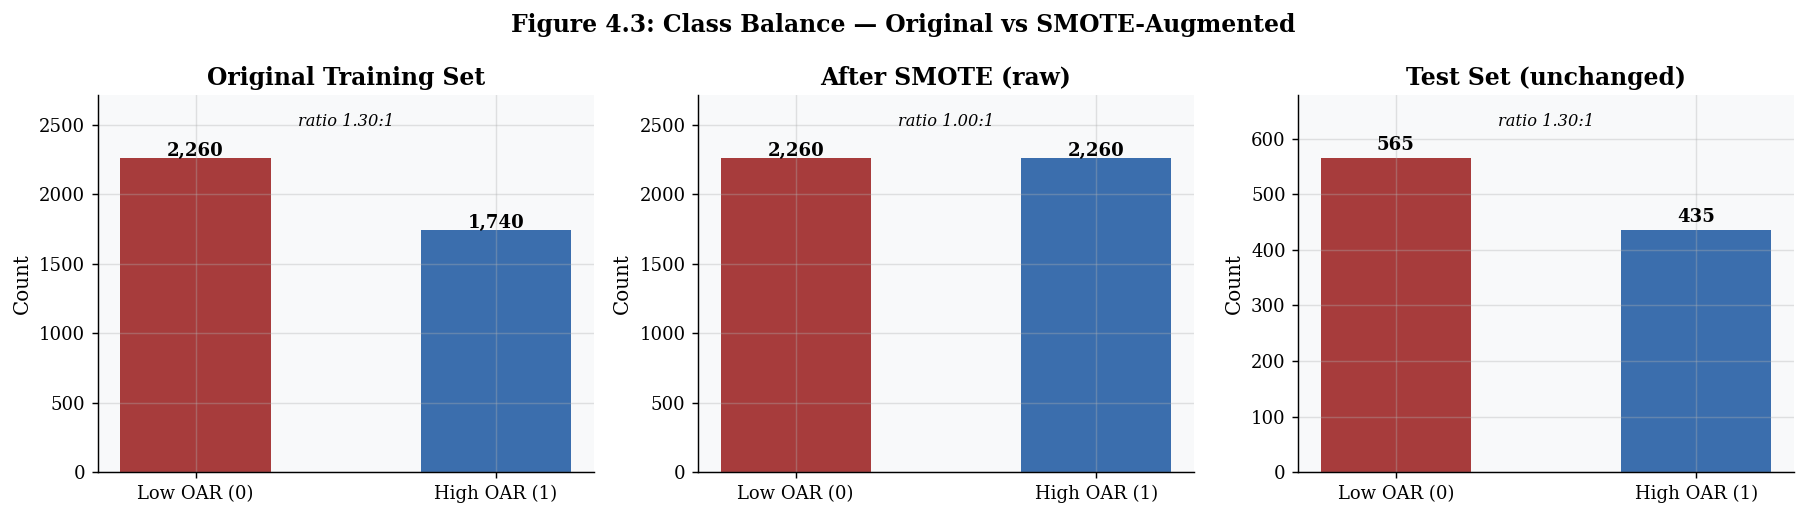

In [9]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# ── Apply SMOTE to the raw (unscaled) training set
# SMOTE is applied before scaling because it operates in the original feature space. 
# Scaling is then applied to the SMOTE-augmented set.
# NOTE: SMOTE is applied ONLY to X_train_raw — X_test_raw is never modified.

sm = SMOTE(random_state=42, k_neighbors=5)

X_train_smote_raw, y_train_smote = sm.fit_resample(X_train_raw, y_train)
X_train_smote_raw = pd.DataFrame(X_train_smote_raw, columns=X_train_raw.columns)
y_train_smote     = pd.Series(y_train_smote, name='target_high_oar')

print("── SMOTE Results (raw feature space)")
print(f"Before : {Counter(y_train)}")
print(f"After  : {Counter(y_train_smote)}")
print(f"Rows added : {len(y_train_smote) - len(y_train):,}")
print(f"New balance: {y_train_smote.mean()*100:.1f}% High OAR  /  {(1-y_train_smote.mean())*100:.1f}% Low OAR")

# ── Also apply SMOTE to the scaled training set
sm2 = SMOTE(random_state=42, k_neighbors=5)
X_train_smote_std, y_train_smote_std = sm2.fit_resample(X_train_std, y_train)
X_train_smote_std = pd.DataFrame(X_train_smote_std, columns=X_train_std.columns)
y_train_smote_std = pd.Series(y_train_smote_std, name='target_high_oar')

print(f"\nScaled version — rows after SMOTE: {len(X_train_smote_std):,}")

# ── Save SMOTE-augmented datasets
tr_smote_raw = X_train_smote_raw.copy()
tr_smote_raw['target_high_oar'] = y_train_smote.values
tr_smote_raw.to_csv('train_smote_raw.csv', index=False)

tr_smote_std = X_train_smote_std.copy()
tr_smote_std['target_high_oar'] = y_train_smote_std.values
tr_smote_std.to_csv('train_smote_standard_scaled.csv', index=False)

print("\nSaved: train_smote_raw.csv & train_smote_standard_scaled.csv")
print("Note : X_test_raw and X_test_std are unchanged — SMOTE is train-only.")

# ── Visualise class balance before/after
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Figure 4.3: Class Balance — Original vs SMOTE-Augmented',
             fontweight='bold', fontsize=13)

for ax, (y_, title_) in zip(axes, [
    (y_train,       'Original Training Set'),
    (y_train_smote, 'After SMOTE (raw)'),
    (y_test,        'Test Set (unchanged)'),
]):
    cnts  = y_.value_counts().sort_index()
    clrs  = [C['red'], C['blue']]
    bars  = ax.bar(['Low OAR (0)','High OAR (1)'], cnts.values,
                   color=clrs, alpha=0.85, width=0.5)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+15,
                f'{int(b.get_height()):,}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title_); ax.set_ylabel('Count')
    ax.set_ylim(0, cnts.max()*1.2)
    ratio = cnts.get(0, 0) / max(cnts.get(1, 1), 1)
    ax.text(0.5, 0.92, f'ratio {ratio:.2f}:1',
            ha='center', transform=ax.transAxes, fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('fig_4.3_smote_balance.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. Model Development

## 5.1. Data Loading & Validation

In [10]:
# ── Load Datasets
train_raw  = pd.read_csv('train_smote_raw.csv')
test_raw   = pd.read_csv('test_raw.csv')
df_orig    = pd.read_csv('recruitment_efficiency_improved.csv')

FEATURE_COLS = [
    'cost_per_applicant', 'cost_per_day', 'applicants_per_day',
    'is_senior_role', 'difficulty_additive', 'drei',
    'dept_oar_mean', 'jobtitle_oar_mean', 'source_oar_mean', 'dept_source_oar_mean'
]
TARGET_COL = 'target_high_oar'

X_train = train_raw[FEATURE_COLS].copy()
y_train = train_raw[TARGET_COL].copy()
X_test  = test_raw[FEATURE_COLS].copy()
y_test  = test_raw[TARGET_COL].copy()

# Replace infinite values
for df in [X_train, X_test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    for col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

# ── Reconstruct Best XGBoost Model
xgb_model = XGBClassifier(
    n_estimators      = 317,
    max_depth         = 8,
    learning_rate     = 0.06420330336297862,
    subsample         = 0.9706635463175177,
    colsample_bytree  = 0.7246844304357644,
    min_child_weight  = 2,
    gamma             = 0.2600340105889054,
    reg_alpha         = 0.006295301484516136,
    reg_lambda        = 0.009456951897345888,
    eval_metric       = 'logloss',
    random_state      = 42,
    use_label_encoder = False,
)

xgb_model.fit(X_train, y_train)

# Evaluate on test set
y_pred      = xgb_model.predict(X_test)
y_prob      = xgb_model.predict_proba(X_test)[:, 1]

print('── XGBoost — Test Set Performance (Stage 2 Reproduction Check)')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Low OAR (0)', 'High OAR (1)']))

── XGBoost — Test Set Performance (Stage 2 Reproduction Check)
  Accuracy  : 0.6380
  Precision : 0.5929
  Recall    : 0.5356
  F1-Score  : 0.5628
  AUC-ROC   : 0.7060

              precision    recall  f1-score   support

 Low OAR (0)       0.67      0.72      0.69       565
High OAR (1)       0.59      0.54      0.56       435

    accuracy                           0.64      1000
   macro avg       0.63      0.63      0.63      1000
weighted avg       0.63      0.64      0.64      1000



In [11]:
import joblib, os

os.makedirs("models", exist_ok=True)

artefacts = {
    # ① Best model
    "model": xgb_model,

    # ② Feature list
    "final_features": FINAL_FEATURES,

    # ③ Target encoding maps (fitted on train only)
    "dept_map":     dept_map,
    "jobtitle_map": jobtitle_map,
    "source_map":   source_map,
    "deptsrc_map":  deptsrc_map,
    "global_mean":  GLOBAL_MEAN,
    "smooth_k":     SMOOTH_K,

    # ④ Scaling stats for difficulty_additive (fitted on train only)
    "time_mean_train": time_mean_train,
    "time_std_train":  time_std_train,
    "cost_mean_train": cost_mean_train,
    "cost_std_train":  cost_std_train,

    # ⑤ Department medians for DREI (fitted on train only)
    "dept_medians": dept_medians,   # columns: dept_median_cph, dept_median_tth, dept_median_oar
}

joblib.dump(artefacts, "models/recruitment_model.joblib")
print("✅ Model and artefacts saved to models/recruitment_model.joblib")

✅ Model and artefacts saved to models/recruitment_model.joblib
